In [5]:
!pip install mediapipe opencv-python scikit-learn pandas numpy matplotlib seaborn joblib -q

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

print("mediapipe version:", mp.__version__)

# Download the hand landmark model once per session (small file, cached under /content)
import os
MODEL_PATH = "/content/hand_landmarker.task"
if not os.path.exists(MODEL_PATH):
    !wget -q -O {MODEL_PATH} https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

assert os.path.exists(MODEL_PATH) and os.path.getsize(MODEL_PATH) > 0, "Model download failed — check your internet connection and re-run this cell."
print("hand_landmarker.task downloaded ✅  size:", os.path.getsize(MODEL_PATH), "bytes")

mediapipe version: 1.0.1
hand_landmarker.task downloaded ✅  size: 7819105 bytes


In [8]:
import os
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/Gesture Image Data"


Mounted at /content/drive


In [9]:
import os

classes = sorted(os.listdir(DATASET_PATH))
print(f"Found {len(classes)} classes:")
print(classes)

Found 36 classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [10]:

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
image_options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5
)
image_detector = mp_vision.HandLandmarker.create_from_options(image_options)


def normalize_landmarks(coords, handedness_label=None):

    c = coords.copy()

    if handedness_label == "Left":
        c[:, 0] = -c[:, 0]

    wrist = c[0]
    c = c - wrist
    ref_vec = c[9]
    ref_len = np.linalg.norm(ref_vec)
    if ref_len == 0:
        return None

    angle = np.arctan2(ref_vec[1], ref_vec[0])
    target_angle = -np.pi / 2
    rotation = target_angle - angle
    cos_a, sin_a = np.cos(rotation), np.sin(rotation)
    rotation_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    c = c @ rotation_matrix.T
    c = c / ref_len

    return c


def extract_landmarks(image_path):
    bgr_image = cv2.imread(image_path)
    if bgr_image is None:
        return None

    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    result = image_detector.detect(mp_image)

    if not result.hand_landmarks:
        return None

    landmarks = result.hand_landmarks[0]
    coords = np.array([[lm.x, lm.y] for lm in landmarks])
    handedness_label = None
    if result.handedness:
        handedness_label = result.handedness[0][0].category_name

    normalized = normalize_landmarks(coords, handedness_label)
    if normalized is None:
        return None

    return normalized.flatten()

_test_class = classes[0]
_test_folder = os.path.join(DATASET_PATH, _test_class)
_test_img = os.path.join(_test_folder, os.listdir(_test_folder)[0])
_test_features = extract_landmarks(_test_img)
if _test_features is not None:
    print(f"Self-test OK — extracted {_test_features.shape[0]} features from a sample '{_test_class}' image.")
else:
    print(f"Self-test found NO hand in the first '{_test_class}' image.")


Self-test OK — extracted 42 features from a sample '0' image.


In [11]:
X = []
y = []
failed_counts = {}

for label in classes:
    class_folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_folder):
        continue

    images = os.listdir(class_folder)
    fail_count = 0

    for img_name in images:
        img_path = os.path.join(class_folder, img_name)
        features = extract_landmarks(img_path)

        if features is None:
            fail_count += 1
            continue

        X.append(features)
        y.append(label)

    failed_counts[label] = fail_count
    print(f"Class '{label}': {len(images) - fail_count}/{len(images)} images processed successfully")

X = np.array(X)
y = np.array(y)

print("\nFinal dataset shape:")
print("X:", X.shape, "  y:", y.shape)
print("\nTotal images with no hand detected (skipped):", sum(failed_counts.values()))

Class '0': 29/70 images processed successfully
Class '1': 60/70 images processed successfully
Class '2': 49/70 images processed successfully
Class '3': 68/70 images processed successfully
Class '4': 69/70 images processed successfully
Class '5': 70/70 images processed successfully
Class '6': 51/70 images processed successfully
Class '7': 65/70 images processed successfully
Class '8': 61/70 images processed successfully
Class '9': 70/70 images processed successfully
Class 'A': 54/112 images processed successfully
Class 'B': 105/113 images processed successfully
Class 'C': 69/113 images processed successfully
Class 'D': 106/113 images processed successfully
Class 'E': 62/113 images processed successfully
Class 'F': 109/112 images processed successfully
Class 'G': 90/112 images processed successfully
Class 'H': 87/112 images processed successfully
Class 'I': 93/117 images processed successfully
Class 'J': 46/109 images processed successfully
Class 'K': 107/113 images processed successfull

In [12]:
columns = [f"{axis}{i}" for i in range(21) for axis in ("x", "y")]
df = pd.DataFrame(X, columns=columns)
df["label"] = y

output_csv = "/content/drive/MyDrive/sign_language_landmarks.csv"
df.to_csv(output_csv, index=False)
print(f"Saved {len(df)} samples to {output_csv}")
df.head()

Saved 2641 samples to /content/drive/MyDrive/sign_language_landmarks.csv


,x0,y0,x1,y1,x2,y2,x3,y3,x4,y4,...,y16,x17,y17,x18,y18,x19,y19,x20,y20,label
0,0.0,0.0,0.429705,-0.244205,0.607739,-0.530784,0.813617,-0.676892,0.895332,-0.813130,...,-0.953348,0.150811,-0.817413,0.582307,-1.107119,0.821385,-1.010325,0.892782,-0.864851,0
1,0.0,0.0,0.448962,-0.282640,0.624371,-0.609600,0.822987,-0.787017,0.979822,-0.934117,...,-1.076215,0.182801,-0.826898,0.566250,-1.178897,0.850714,-1.127501,0.999133,-1.002178,0
2,0.0,0.0,0.414212,-0.284909,0.605023,-0.601111,0.810832,-0.777641,0.966760,-0.949910,...,-1.097969,0.186795,-0.816548,0.565018,-1.203043,0.852263,-1.158279,0.995494,-1.029171,0
3,0.0,0.0,0.431075,-0.259139,0.622663,-0.512891,0.830952,-0.681606,0.879693,-0.827646,...,-0.859323,0.105733,-0.841810,0.520034,-1.012205,0.767280,-0.927423,0.898609,-0.806166,0
4,0.0,0.0,0.418037,-0.208323,0.631526,-0.488961,0.793821,-0.734617,0.753721,-0.982409,...,-0.881514,-0.120756,-0.836416,0.150256,-0.997168,0.389665,-0.975824,0.554203,-0.897407,0


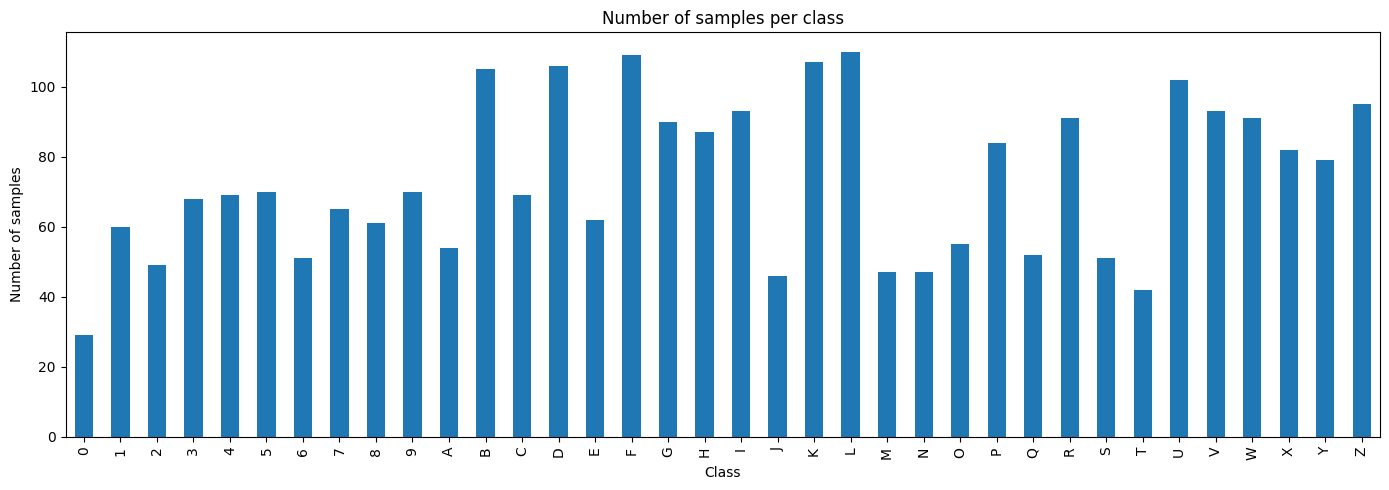

In [13]:
plt.figure(figsize=(14, 5))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of samples per class")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)
print("Classes:", list(label_encoder.classes_))

Train size: (2112, 42)
Test size: (529, 42)
Classes: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z')]


In [15]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.9490
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       1.00      1.00      1.00        12
           2       1.00      0.80      0.89        10
           3       1.00      1.00      1.00        14
           4       0.86      0.86      0.86        14
           5       0.87      0.93      0.90        14
           6       0.90      0.90      0.90        10
           7       1.00      1.00      1.00        13
           8       1.00      0.92      0.96        12
           9       1.00      1.00      1.00        14
           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        21
           C       0.93      0.93      0.93        14
           D       1.00      1.00      1.00        21
           E       0.92      1.00      0.96        12
           F       1.00      0.95      0.98        22
           G       1.00      0.89      0.94       

In [16]:
svm_model = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_acc:.4f}")
print(classification_report(y_test, svm_pred, target_names=label_encoder.classes_))

SVM Accuracy: 0.9546
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       1.00      1.00      1.00        12
           2       0.78      0.70      0.74        10
           3       1.00      1.00      1.00        14
           4       0.92      0.86      0.89        14
           5       0.87      0.93      0.90        14
           6       0.71      1.00      0.83        10
           7       1.00      1.00      1.00        13
           8       1.00      1.00      1.00        12
           9       1.00      1.00      1.00        14
           A       0.92      1.00      0.96        11
           B       1.00      1.00      1.00        21
           C       0.87      0.93      0.90        14
           D       1.00      1.00      1.00        21
           E       1.00      1.00      1.00        12
           F       1.00      1.00      1.00        22
           G       1.00      0.89      0.94        18
      

In [17]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)

mlp_pred = mlp_model.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, mlp_pred)

print(f"Neural Network (MLP) Accuracy: {mlp_acc:.4f}")
print(classification_report(y_test, mlp_pred, target_names=label_encoder.classes_))

Neural Network (MLP) Accuracy: 0.9603
              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       1.00      1.00      1.00        12
           2       1.00      0.80      0.89        10
           3       1.00      1.00      1.00        14
           4       0.88      1.00      0.93        14
           5       1.00      0.93      0.96        14
           6       0.83      1.00      0.91        10
           7       1.00      1.00      1.00        13
           8       1.00      0.92      0.96        12
           9       1.00      1.00      1.00        14
           A       0.91      0.91      0.91        11
           B       1.00      1.00      1.00        21
           C       0.92      0.86      0.89        14
           D       0.95      1.00      0.98        21
           E       1.00      1.00      1.00        12
           F       1.00      1.00      1.00        22
           G       1.00      0.89      0.94

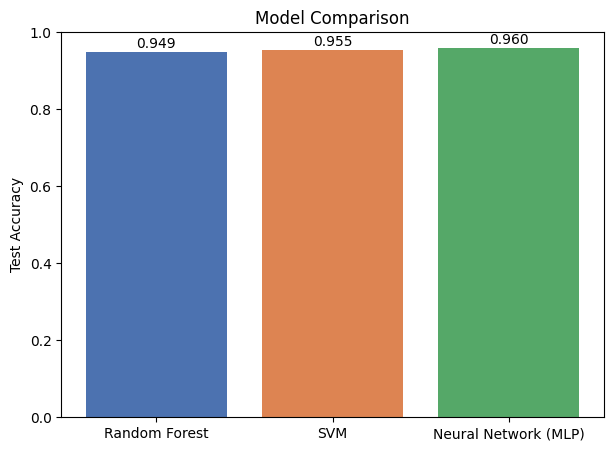

Best model: Neural Network (MLP) (0.9603 accuracy)


In [18]:
results = {
    "Random Forest": rf_acc,
    "SVM": svm_acc,
    "Neural Network (MLP)": mlp_acc,
}

plt.figure(figsize=(7, 5))
plt.bar(results.keys(), results.values(), color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha="center")
plt.show()

best_model_name = max(results, key=results.get)
print(f"Best model: {best_model_name} ({results[best_model_name]:.4f} accuracy)")

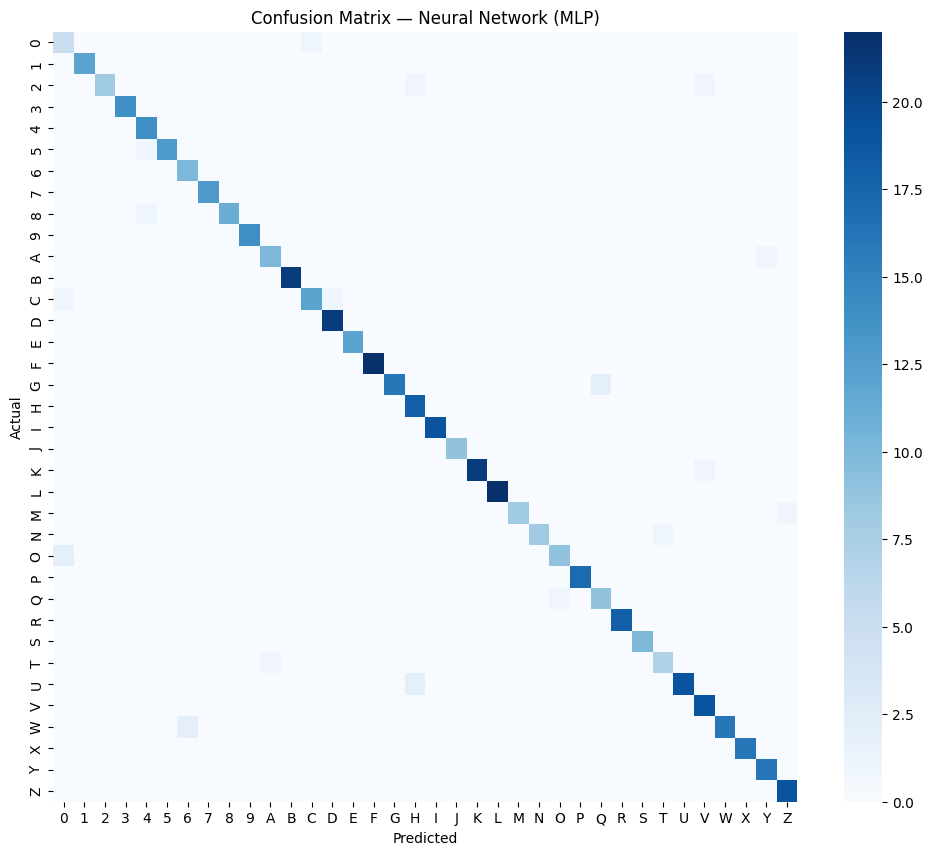

In [19]:
# Confusion matrix for the best model (example shown for Random Forest — swap variables as needed)
models = {"Random Forest": (rf_model, rf_pred), "SVM": (svm_model, svm_pred), "Neural Network (MLP)": (mlp_model, mlp_pred)}
best_model, best_pred = models[best_model_name]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
save_dir = "/content/drive/MyDrive/sign_language_model"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(save_dir, "best_model.pkl"))
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
joblib.dump(label_encoder, os.path.join(save_dir, "label_encoder.pkl"))

print(f"Saved best model ({best_model_name}), scaler, and label encoder to: {save_dir}")

Saved best model (Neural Network (MLP)), scaler, and label encoder to: /content/drive/MyDrive/sign_language_model


In [62]:
# ============================================================
# OPTION B — capture ONE photo from webcam inside Colab and predict on it
# ============================================================
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Take a photo, then predict using the SAME normalization as training
photo_path = take_photo()
features = extract_landmarks(photo_path)   # reuse the Step 3 function (static image mode)

if features is None:
    print("No hand detected — try again with better lighting / hand fully in frame.")
else:
    features_scaled = scaler.transform([features])
    pred = best_model.predict(features_scaled)[0]
    label = label_encoder.inverse_transform([pred])[0]
    print(f"Predicted sign: {label}")

<IPython.core.display.Javascript object>

Predicted sign: 7
